# Regressão Logística — Efeitos dos Atributos via AME

Este notebook mensura o impacto de cada atributo no desfecho do sinistro (`grave`)
usando os **Efeitos Marginais Médios (AME)** como medida de efeito.

$$AME_k = E\left[\frac{\partial P(Y=1 \mid X)}{\partial x_k}\right]$$

O AME expressa a **variação média na probabilidade prevista** do evento associada
a uma variação unitária em $x_k$ — mesma escala e interpretação do
`SHAP_global_E[φ_k]` calculado nos demais modelos (RF e CatBoost),
tornando direta a comparação entre frameworks.

> **Nota:** este notebook usa **exatamente as mesmas colunas e a mesma divisão
> temporal** da base tratada utilizada por Random Forest e CatBoost
> (`df_train.csv` / `df_test.csv`), garantindo comparabilidade dos resultados.


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


## 1. Carga dos dados

In [2]:
URL_TRAIN = "../../database/completo/final/df_train.csv"
URL_TEST  = "../../database/completo/final/df_test.csv"

df_train = pd.read_csv(URL_TRAIN, encoding="UTF-8")
df_test  = pd.read_csv(URL_TEST,  encoding="UTF-8")

# Separação X / y  — mesmas colunas dos demais modelos
X_train = df_train.drop(columns=["grave", "ano"])
y_train = df_train["grave"]

X_test = df_test.drop(columns=["grave", "ano"])
y_test = df_test["grave"]

print(f"Treino : {X_train.shape}  |  Teste: {X_test.shape}")
print(f"Colunas: {list(X_train.columns)}")


Treino : (558847, 20)  |  Teste: (72310, 20)
Colunas: ['sentido_via', 'pista_molhada', 'visibilidade_ruim', 'tipo_pista', 'uso_solo', 'intersecao_de_vias', 'reta', 'declive', 'condicao_ignorada', 'feriado', 'vel_max', 'distancia_radar_m', 'frequencia', 'uf_br_km', 'turno_sin', 'turno_cos', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos']


## 2. Treinamento — Regressão Logística (statsmodels)

In [3]:
# ─────────────────────────────────────────────────────────────────────
# Pesos de classe — equivalente ao class_weight='balanced' do sklearn.
# Cada observação recebe peso inversamente proporcional à frequência
# de sua classe, de forma que as classes contribuem igualmente para
# a função de log-verossimilhança ponderada.
# ─────────────────────────────────────────────────────────────────────
n_neg   = (y_train == 0).sum()
n_pos   = (y_train == 1).sum()
n_total = len(y_train)

w0 = n_total / (2 * n_neg)   # peso da classe 0 (maioria)
w1 = n_total / (2 * n_pos)   # peso da classe 1 (minoria)
pesos = y_train.map({0: w0, 1: w1})

print(f"Desbalanceamento — negativos: {n_neg:,} | positivos: {n_pos:,}")
print(f"Peso classe 0: {w0:.4f} | Peso classe 1: {w1:.4f}")

X_train_const = sm.add_constant(X_train)
modelo = sm.Logit(y_train, X_train_const, freq_weights=pesos)
resultado_fit = modelo.fit(method="bfgs", maxiter=500, disp=False)

print(f"\nPseudo R² de McFadden : {resultado_fit.prsquared:.4f}")
print(f"Log-likelihood        : {resultado_fit.llf:.2f}")


Desbalanceamento — negativos: 486,401 | positivos: 72,446
Peso classe 0: 0.5745 | Peso classe 1: 3.8570

Pseudo R² de McFadden : 0.1086
Log-likelihood        : -192136.58


## 3. Avaliação no conjunto de teste

In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

X_test_const = sm.add_constant(X_test, has_constant='add')
y_prob = resultado_fit.predict(X_test_const)
y_pred = (y_prob >= 0.5).astype(int)

print("=== Métricas (Teste 2025) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred))


=== Métricas (Teste 2025) ===
Accuracy : 0.8513
Precision: 0.2523
Recall   : 0.0274
F1-score : 0.0495
AUC      : 0.5863

              precision    recall  f1-score   support

           0       0.86      0.99      0.92     62109
           1       0.25      0.03      0.05     10201

    accuracy                           0.85     72310
   macro avg       0.56      0.51      0.48     72310
weighted avg       0.77      0.85      0.80     72310



## 4. Efeitos Marginais Médios (AME)

In [5]:
# ─────────────────────────────────────────────────────────────────────
# get_margeff(at='overall', method='dydx')
#   Para cada observação i calcula:  dP/dxk(i) = β_k · P̂(i) · (1 - P̂(i))
#   e retorna a média sobre toda a amostra de treino:  AME_k = E[dP/dxk]
#
# at='overall' → AME verdadeiro (média das derivadas individuais).
# Diferente de at='mean' → MEM (derivada avaliada na média das covariáveis).
# ─────────────────────────────────────────────────────────────────────
margeff = resultado_fit.get_margeff(at='overall', method='dydx')

ame_df = pd.DataFrame({
    "AME"       : margeff.margeff,
    "EP"        : margeff.margeff_se,
    "p_valor"   : margeff.pvalues,
    "IC_95_inf" : margeff.conf_int()[:, 0],
    "IC_95_sup" : margeff.conf_int()[:, 1],
}, index=X_train.columns)

ame_df["AME_abs"]       = ame_df["AME"].abs()
ame_df["significativo"] = ame_df["p_valor"] < 0.05
ame_df = ame_df.sort_values("AME_abs", ascending=False)

print("=== Impacto dos atributos — Regressão Logística ===")
print("AME         → efeito médio com sinal, em unidades de probabilidade")
print("AME_abs     → importância absoluta, para ranqueamento")
print()
print(ame_df[["AME", "AME_abs", "p_valor"]].to_string(float_format="{:.6f}".format))


=== Impacto dos atributos — Regressão Logística ===
AME         → efeito médio com sinal, em unidades de probabilidade
AME_abs     → importância absoluta, para ranqueamento

                         AME  AME_abs  p_valor
uf_br_km            1.740513 1.740513 0.000000
vel_max             0.036786 0.036786 0.000000
frequencia          0.036177 0.036177 0.000000
condicao_ignorada   0.030599 0.030599 0.000000
pista_molhada      -0.018537 0.018537 0.000083
declive             0.014745 0.014745 0.000000
turno_cos           0.014114 0.014114 0.000000
intersecao_de_vias -0.010895 0.010895 0.000000
turno_sin          -0.010615 0.010615 0.000000
dia_semana_sin     -0.007552 0.007552 0.000000
distancia_radar_m   0.007128 0.007128 0.000161
visibilidade_ruim  -0.006307 0.006307 0.167651
uso_solo           -0.005429 0.005429 0.000000
tipo_pista         -0.004503 0.004503 0.000000
reta               -0.003420 0.003420 0.000391
mes_sin            -0.002560 0.002560 0.000025
mes_cos            -0.00216

## 5. Significância estatística

In [6]:
print("=== Significância dos AMEs (α = 0,05) ===")
print(f"{'Variável':35s}  {'AME':>9}  {'p-valor':>9}  Sig.")
print("-" * 62)

for var, row in ame_df.iterrows():
    sig = "*" if row["significativo"] else ""
    print(f"{var:35s}  {row['AME']:>+9.4f}  {row['p_valor']:>9.4f}  {sig}")

print("\n* p-valor < 0,05")


=== Significância dos AMEs (α = 0,05) ===
Variável                                   AME    p-valor  Sig.
--------------------------------------------------------------
uf_br_km                               +1.7405     0.0000  *
vel_max                                +0.0368     0.0000  *
frequencia                             +0.0362     0.0000  *
condicao_ignorada                      +0.0306     0.0000  *
pista_molhada                          -0.0185     0.0001  *
declive                                +0.0147     0.0000  *
turno_cos                              +0.0141     0.0000  *
intersecao_de_vias                     -0.0109     0.0000  *
turno_sin                              -0.0106     0.0000  *
dia_semana_sin                         -0.0076     0.0000  *
distancia_radar_m                      +0.0071     0.0002  *
visibilidade_ruim                      -0.0063     0.1677  
uso_solo                               -0.0054     0.0000  *
tipo_pista                             

## 6. Visualizações

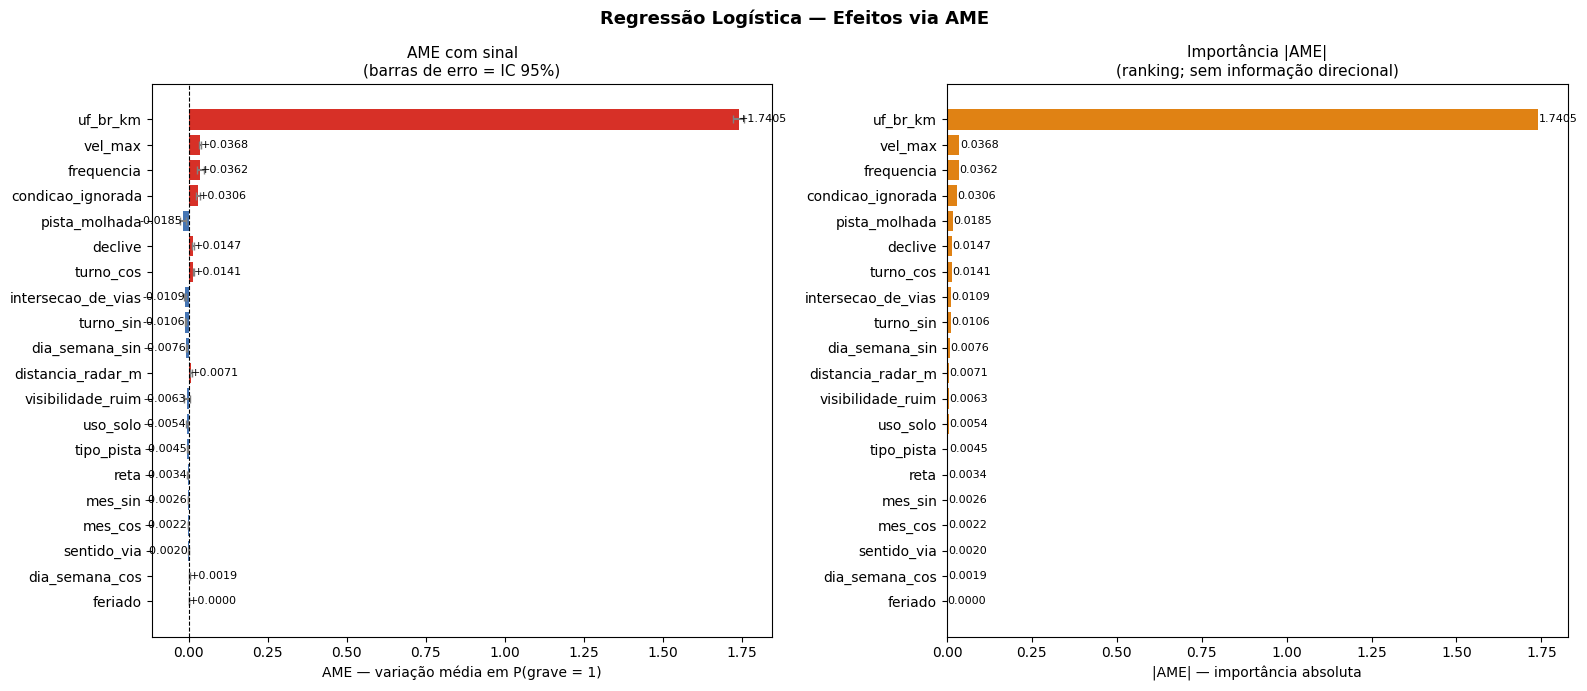

Gráfico salvo em logit_ame_efeitos.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Regressão Logística — Efeitos via AME", fontsize=13, fontweight='bold')

# ── Gráfico 1: AME com sinal e IC 95% ──────────────────────────────
cores    = ['#d73027' if v > 0 else '#4575b4' for v in ame_df["AME"]]
yerr_low  = ame_df["AME"] - ame_df["IC_95_inf"]
yerr_high = ame_df["IC_95_sup"] - ame_df["AME"]

bars = axes[0].barh(
    ame_df.index, ame_df["AME"],
    xerr=[yerr_low, yerr_high],
    color=cores, ecolor='gray', capsize=3
)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel("AME — variação média em P(grave = 1)")
axes[0].set_title("AME com sinal\n(barras de erro = IC 95%)", fontsize=11)
axes[0].invert_yaxis()

# rótulos de valor
for bar, val in zip(bars, ame_df["AME"]):
    x_pos = val + (yerr_high.iloc[list(ame_df["AME"]).index(val)] if val >= 0
                   else -yerr_low.iloc[list(ame_df["AME"]).index(val)])
    axes[0].text(
        bar.get_width() + (0.001 if bar.get_width() >= 0 else -0.001),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.4f}",
        va='center', ha='left' if val >= 0 else 'right', fontsize=8
    )

# ── Gráfico 2: importância absoluta ────────────────────────────────
bars2 = axes[1].barh(ame_df.index, ame_df["AME_abs"], color='#e08214')
axes[1].set_xlabel("|AME| — importância absoluta")
axes[1].set_title("Importância |AME|\n(ranking; sem informação direcional)", fontsize=11)
axes[1].invert_yaxis()

for bar, val in zip(bars2, ame_df["AME_abs"]):
    axes[1].text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va='center', ha='left', fontsize=8
    )

plt.tight_layout()
plt.savefig("logit_ame_efeitos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em logit_ame_efeitos.png")


## 7. Exportação — formato compatível com tabelas SHAP

In [8]:
# Exporta com os mesmos nomes de coluna das tabelas SHAP dos demais modelos
# para facilitar a comparação direta entre frameworks.
tabela_export = ame_df[["AME", "AME_abs", "p_valor", "IC_95_inf", "IC_95_sup"]].copy()
tabela_export.columns = [
    "SHAP_global_E[phi_k]",
    "SHAP_importancia_E[|phi_k|]",
    "p_valor",
    "IC_95_inf",
    "IC_95_sup"
]

print("=== Tabela no formato SHAP (para comparação entre modelos) ===")
print(tabela_export[["SHAP_global_E[phi_k]", "SHAP_importancia_E[|phi_k|]"]].to_string())

tabela_export.to_csv("logit_ames.csv")
print("\nSalvo em logit_ames.csv")


=== Tabela no formato SHAP (para comparação entre modelos) ===
                    SHAP_global_E[phi_k]  SHAP_importancia_E[|phi_k|]
uf_br_km                    1.740513e+00                 1.740513e+00
vel_max                     3.678564e-02                 3.678564e-02
frequencia                  3.617735e-02                 3.617735e-02
condicao_ignorada           3.059943e-02                 3.059943e-02
pista_molhada              -1.853737e-02                 1.853737e-02
declive                     1.474514e-02                 1.474514e-02
turno_cos                   1.411412e-02                 1.411412e-02
intersecao_de_vias         -1.089475e-02                 1.089475e-02
turno_sin                  -1.061502e-02                 1.061502e-02
dia_semana_sin             -7.551574e-03                 7.551574e-03
distancia_radar_m           7.128137e-03                 7.128137e-03
visibilidade_ruim          -6.306841e-03                 6.306841e-03
uso_solo                   

## 8. Sumário completo do modelo

In [9]:
print(resultado_fit.summary2())


                           Results: Logit
Model:                Logit            Pseudo R-squared: 0.109      
Dependent Variable:   grave            AIC:              384315.1623
Date:                 2026-04-30 14:07 BIC:              384551.0685
No. Observations:     558847           Log-Likelihood:   -1.9214e+05
Df Model:             20               LL-Null:          -2.1554e+05
Df Residuals:         558826           LLR p-value:      0.0000     
Converged:            1.0000           Scale:            1.0000     
Method:               MLE                                           
--------------------------------------------------------------------
                    Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
--------------------------------------------------------------------
const              -4.3701   0.0198 -220.2542 0.0000 -4.4090 -4.3313
sentido_via        -0.0195   0.0084   -2.3091 0.0209 -0.0360 -0.0029
pista_molhada      -0.1827   0.0464   -3.9360 0.0001 -0.2737 

## 9. Análise das variáveis cíclicas via AME

As variáveis temporais (turno, dia_semana, mes) foram codificadas via sin/cos encoding.
Na regressão logística, cada variável cíclica origina **dois coeficientes**: β_sin e β_cos.
O efeito do período original é recuperado projetando os AMEs desses componentes
sobre cada posição do ciclo:

$$\text{efeito}(v) = AME_{\sin} \cdot \sin(\theta_v) + AME_{\cos} \cdot \cos(\theta_v)$$

onde $\theta_v = 2\pi(v - \delta) / P$, com $P$ = período e $\delta$ = offset.

Esta projeção está **na mesma escala de probabilidade** dos AMEs individuais e dos
gráficos cíclicos SHAP de RF e CatBoost, tornando a comparação entre modelos direta.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────
# Utilitários para análise cíclica via AME
# ─────────────────────────────────────────────────────────────────────

def ame_cyclic_importance(ame_df, sin_name, cos_name):
    """
    Métricas de importância cíclica a partir dos AMEs dos componentes sin/cos.

    Análogo exato de cyclic_importance() dos notebooks SHAP,
    mas baseado nos AMEs da regressão logística.

    Retorna:
        importance_cyclic  : sqrt(AME_sin² + AME_cos²) — magnitude do vetor AME
        direction_amplitude: mesmo valor (para AME global é determinístico)
        ame_sin / ame_cos  : efeitos marginais dos componentes
        dominant_phase_deg : fase dominante em graus (onde o efeito é máximo)
    """
    ame_sin = ame_df.loc[sin_name, "AME"] if sin_name in ame_df.index else 0.0
    ame_cos = ame_df.loc[cos_name, "AME"] if cos_name in ame_df.index else 0.0

    importance = np.sqrt(ame_sin**2 + ame_cos**2)
    # fase onde o efeito é máximo: θ* = atan2(AME_sin, AME_cos)
    dominant_phase_rad = np.arctan2(ame_sin, ame_cos)
    dominant_phase_deg = np.degrees(dominant_phase_rad) % 360

    return {
        "importance_cyclic"  : float(importance),
        "direction_amplitude": float(importance),   # idêntico para AME global
        "ame_sin"            : float(ame_sin),
        "ame_cos"            : float(ame_cos),
        "dominant_phase_deg" : float(dominant_phase_deg),
    }


def plot_ame_cyclic_effect(ame_df, sin_name, cos_name, labels, offset=0,
                           save_path=None):
    """
    Projeta os AMEs dos componentes sin/cos sobre cada posição do ciclo
    e plota o efeito médio com rótulos de valor em cada ponto.

    Produz gráfico na mesma escala e layout de plot_cyclic_effect() (SHAP),
    permitindo comparação visual direta entre os três modelos.

    Parâmetros:
        ame_df    : DataFrame com coluna 'AME' e índice = nomes das variáveis
        sin_name  : nome do componente _sin  (ex: 'turno_sin')
        cos_name  : nome do componente _cos  (ex: 'turno_cos')
        labels    : rótulos de cada posição do ciclo
        offset    : ajuste de fase (1 para mês, 0 para os demais)
        save_path : caminho para salvar a figura (None = não salva)
    """
    ame_sin = ame_df.loc[sin_name, "AME"] if sin_name in ame_df.index else 0.0
    ame_cos = ame_df.loc[cos_name, "AME"] if cos_name in ame_df.index else 0.0
    sig_sin = ame_df.loc[sin_name, "significativo"] if sin_name in ame_df.index else False
    sig_cos = ame_df.loc[cos_name, "significativo"] if cos_name in ame_df.index else False

    period = len(labels)
    theta  = 2 * np.pi * (np.arange(period) - offset) / period
    effect = ame_sin * np.sin(theta) + ame_cos * np.cos(theta)

    varname  = sin_name.replace("_sin", "")
    sig_note = ""
    if not sig_sin and not sig_cos:
        sig_note = "  ⚠ AME_sin e AME_cos não significativos (p ≥ 0,05)"
    elif not sig_sin:
        sig_note = "  ⚠ AME_sin não significativo (p ≥ 0,05)"
    elif not sig_cos:
        sig_note = "  ⚠ AME_cos não significativo (p ≥ 0,05)"

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(range(period), effect, marker='o', linewidth=1.8, color='#e08214')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.fill_between(range(period), effect, 0,
                    where=effect > 0, alpha=0.15, color='#d73027')
    ax.fill_between(range(period), effect, 0,
                    where=effect <= 0, alpha=0.15, color='#4575b4')

    # rótulo em cada ponto
    for i, val in enumerate(effect):
        ax.annotate(
            f"{val:+.4f}",
            xy=(i, val),
            xytext=(0, 8 if val >= 0 else -14),
            textcoords='offset points',
            ha='center', fontsize=8, color='#222222'
        )

    ax.set_xticks(range(period))
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_xlabel("Posição no ciclo")
    ax.set_ylabel("AME projetado — variação em P(grave=1)")
    ax.set_title(
        f"Regressão Logística — Efeito cíclico AME: {varname}\n"
        f"efeito(v) = AME_sin·sin(θᵥ) + AME_cos·cos(θᵥ){sig_note}",
        fontsize=10
    )
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Gráfico salvo em {save_path}")
    plt.show()


In [11]:
LABELS_TURNO  = ["Madrugada", "Manhã", "Tarde", "Noite"]
LABELS_SEMANA = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
LABELS_MES    = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
                 "Jul", "Ago", "Set", "Out", "Nov", "Dez"]


### 9.1 Métricas de importância cíclica

In [12]:
print("=== Importância cíclica dos atributos temporais (Regressão Logística) ===")
print("importance_cyclic = sqrt(AME_sin² + AME_cos²)  — magnitude do vetor AME")
print("dominant_phase_deg = ângulo onde o efeito cíclico é máximo")
print()

for sin_name, cos_name in [("turno_sin",      "turno_cos"),
                             ("dia_semana_sin", "dia_semana_cos"),
                             ("mes_sin",        "mes_cos")]:
    varname = sin_name.replace("_sin", "")
    m = ame_cyclic_importance(ame_df, sin_name, cos_name)
    print(f"=== {varname} ===")
    for k, v in m.items():
        print(f"  {k:25s}: {v:.6f}")
    print()


=== Importância cíclica dos atributos temporais (Regressão Logística) ===
importance_cyclic = sqrt(AME_sin² + AME_cos²)  — magnitude do vetor AME
dominant_phase_deg = ângulo onde o efeito cíclico é máximo

=== turno ===
  importance_cyclic        : 0.017660
  direction_amplitude      : 0.017660
  ame_sin                  : -0.010615
  ame_cos                  : 0.014114
  dominant_phase_deg       : 323.053724

=== dia_semana ===
  importance_cyclic        : 0.007786
  direction_amplitude      : 0.007786
  ame_sin                  : -0.007552
  ame_cos                  : 0.001897
  dominant_phase_deg       : 284.097912

=== mes ===
  importance_cyclic        : 0.003351
  direction_amplitude      : 0.003351
  ame_sin                  : -0.002560
  ame_cos                  : -0.002162
  dominant_phase_deg       : 229.816339



### 9.2 Efeito cíclico AME — Turno

Gráfico salvo em logit_ciclo_turno.png


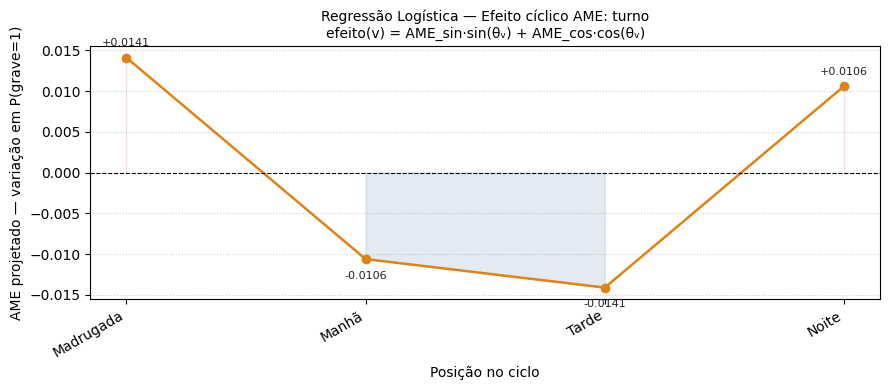

In [13]:
plot_ame_cyclic_effect(
    ame_df,
    "turno_sin", "turno_cos",
    labels=LABELS_TURNO,
    save_path="logit_ciclo_turno.png"
)


### 9.3 Efeito cíclico AME — Dia da semana

Gráfico salvo em logit_ciclo_dia_semana.png


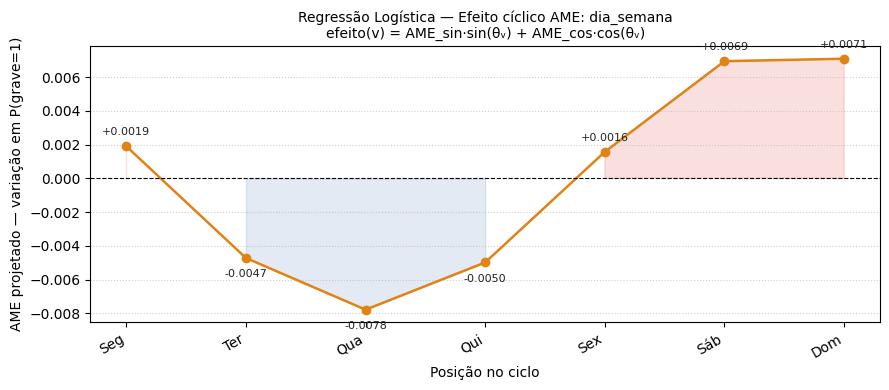

In [14]:
plot_ame_cyclic_effect(
    ame_df,
    "dia_semana_sin", "dia_semana_cos",
    labels=LABELS_SEMANA,
    save_path="logit_ciclo_dia_semana.png"
)


### 9.4 Efeito cíclico AME — Mês

Gráfico salvo em logit_ciclo_mes.png


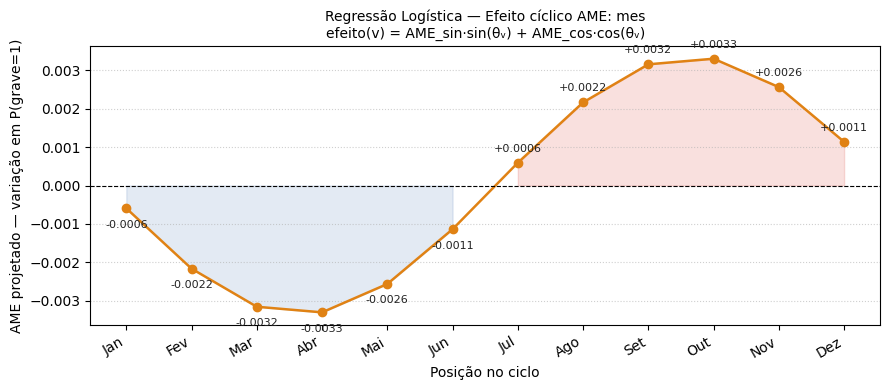

In [16]:
plot_ame_cyclic_effect(
    ame_df,
    "mes_sin", "mes_cos",
    labels=LABELS_MES,
    offset=1,
    save_path="logit_ciclo_mes.png"
)


### 9.5 Comparação dos efeitos cíclicos entre os três modelos

Os gráficos acima usam a mesma escala de probabilidade e o mesmo layout
dos gráficos cíclicos SHAP de RF e CatBoost, possibilitando comparação direta.

**Como interpretar a diferença entre métodos:**

| Aspecto | AME (Logit) | SHAP (RF / CatBoost) |
|---|---|---|
| Origem do efeito | Projeção de β_sin e β_cos via derivada marginal | Projeção de φ_sin(i) e φ_cos(i) via valor de Shapley |
| Forma da curva | Senoide suave (linear por construção) | Pode ter forma irregular (captura não linearidades) |
| Interpretação | Efeito marginal médio do ciclo, controlando demais variáveis | Contribuição média do ciclo para a predição do modelo |
| Escala | Variação em P(grave=1) | Variação em P(grave=1) |

Se as curvas dos três modelos coincidem, o efeito cíclico é robusto e linear.
Se divergem, o ensemble captura padrões não lineares que o logit não representa.
